IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


Load Dataset

In [ ]:
df = pd.read_csv("final_dataset.csv")
print("Dataset Loaded!")
print(df.head())


Dataset Loaded!
  Country  Year  D_Expenditure_GDP  Conflict_Intensity  \
0     USA  1994           4.215265                 NaN   
1     USA  1995           3.860246                 NaN   
2     USA  1996           3.554982                 NaN   
3     USA  1997           3.554982                 NaN   
4     USA  1998           3.201558                 NaN   

   Health_Expenditure_(% of GDP)  Education_Expenditure_(% of GDP)  \
0                            NaN                               NaN   
1                            NaN                               NaN   
2                            NaN                               NaN   
3                            NaN                               NaN   
4                            NaN                               NaN   

   Environmental impact (CO2e/capita)  Refugees  Asylum Seekers  \
0                               19.83       364               0   
1                               19.79       243               0   
2            

Common Input Features

In [ ]:
features = ["D_Expenditure_GDP", "Year", "Country"]


Random Forest Test MODEL for HEALTH

In [ ]:
# ----------------------- HEALTH MODEL -----------------------
target_health = "Health_Expenditure_(% of GDP)"

# Prepare data
data_h = df[features + [target_health]].dropna()
X_h = data_h[features]
y_h = data_h[target_health]

# Preprocessing + model
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["Country"]),
    ("num", "passthrough", ["D_Expenditure_GDP", "Year"])
])

model_h = Pipeline([
    ("prep", preprocess),
    ("rf", RandomForestRegressor(n_estimators=200, random_state=42))
])

# Split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

# Train
model_h.fit(X_train_h, y_train_h)

# Predict
pred_h = model_h.predict(X_test_h)

# Metrics
r2_h = r2_score(y_test_h, pred_h)
mae_h = mean_absolute_error(y_test_h, pred_h)
mse_h = mean_squared_error(y_test_h, pred_h)
rmse_h = np.sqrt(mse_h)

print("\n================ HEALTH METRICS ================")
print("R²:", round(r2_h, 4))
print("MAE:", round(mae_h, 4))
print("MSE:", round(mse_h, 4))
print("RMSE:", round(rmse_h, 4))
print("================================================")



================ HEALTH METRICS ================
R²: 0.9945
MAE: 0.2067
MSE: 0.0951
RMSE: 0.3083


Plot Health Actual vs Predicted

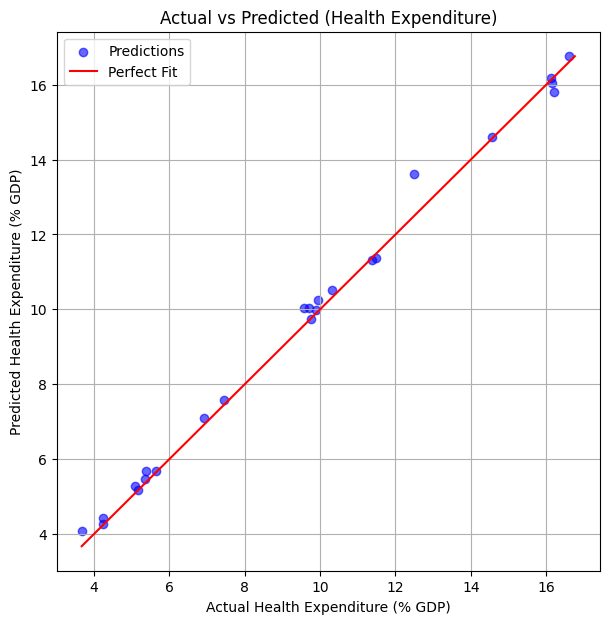

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_h, pred_h, color='blue', alpha=0.6, label='Predictions')

# Perfect fit diagonal line
lim_min = min(min(y_test_h), min(pred_h))
lim_max = max(max(y_test_h), max(pred_h))
plt.plot([lim_min, lim_max], [lim_min, lim_max], color='red', label='Perfect Fit')

plt.xlabel("Actual Health Expenditure (% GDP)")
plt.ylabel("Predicted Health Expenditure (% GDP)")
plt.title("Actual vs Predicted (Health Expenditure)")
plt.legend()
plt.grid(True)
plt.show()


Random Forest TEST MODEL for EDUCATION

In [ ]:
# ----------------------- EDUCATION MODEL -----------------------
target_edu = "Education_Expenditure_(% of GDP)"

# Prepare data
data_e = df[features + [target_edu]].dropna()
X_e = data_e[features]
y_e = data_e[target_edu]

# Same preprocessing + RF model
model_e = Pipeline([
    ("prep", preprocess),
    ("rf", RandomForestRegressor(n_estimators=200, random_state=42))
])

# Split
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_e, y_e, test_size=0.2, random_state=42)

# Train
model_e.fit(X_train_e, y_train_e)

# Predict
pred_e = model_e.predict(X_test_e)

# Metrics
r2_e = r2_score(y_test_e, pred_e)
mae_e = mean_absolute_error(y_test_e, pred_e)
mse_e = mean_squared_error(y_test_e, pred_e)
rmse_e = np.sqrt(mse_e)

print("\n================ EDUCATION METRICS ================")
print("R²:", round(r2_e, 4))
print("MAE:", round(mae_e, 4))
print("MSE:", round(mse_e, 4))
print("RMSE:", round(rmse_e, 4))
print("===================================================")



================ EDUCATION METRICS ================
R²: 0.9578
MAE: 0.1726
MSE: 0.0577
RMSE: 0.2401


Plot Education Actual vs Predicted

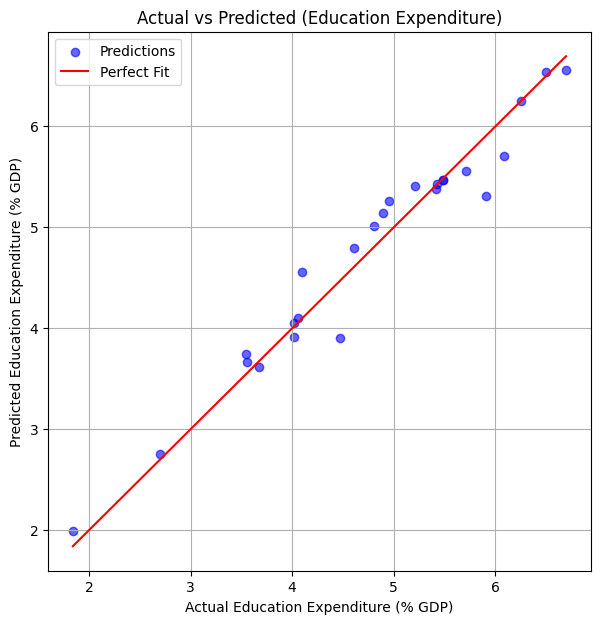

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_e, pred_e, color='blue', alpha=0.6, label='Predictions')

lim_min = min(min(y_test_e), min(pred_e))
lim_max = max(max(y_test_e), max(pred_e))
plt.plot([lim_min, lim_max], [lim_min, lim_max], color='red', label='Perfect Fit')

plt.xlabel("Actual Education Expenditure (% GDP)")
plt.ylabel("Predicted Education Expenditure (% GDP)")
plt.title("Actual vs Predicted (Education Expenditure)")
plt.legend()
plt.grid(True)
plt.show()



COMPARISON TABLE FOR BOTH

In [ ]:
comparison = pd.DataFrame({
    "Metric": ["R² Score", "MAE", "MSE", "RMSE"],
    "Health Model": [round(r2_h, 4), round(mae_h, 4), round(mse_h, 4), round(rmse_h, 4)],
    "Education Model": [round(r2_e, 4), round(mae_e, 4), round(mse_e, 4), round(rmse_e, 4)]
})

print("\n==================== COMPARISON TABLE ====================")
print(comparison.to_string(index=False))
print("==========================================================")



==================== COMPARISON TABLE ====================
  Metric  Health Model  Education Model
R² Score        0.9945           0.9578
     MAE        0.2067           0.1726
     MSE        0.0951           0.0577
    RMSE        0.3083           0.2401
